<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Modelo de Puntuación Crediticia PyMES

<font color='black'>

- Diego Lozoya Morales
- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Arantza Gomez Haro Gamboa
- Javier Alejandro Fajardo López
- Luis Fernando Márquez Bañuelos

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

In [2]:
df_tickers = pd.read_csv('tickers_bmv_yahoo.csv')
all_tickers = df_tickers['YAHOO_TICKER'].tolist()

## <font color='cornflowerblue'> Financials

In [3]:
def get_financials(ticker:str) -> pd.DataFrame:
    bs = yf.Ticker(ticker).balance_sheet.iloc[:, :1]
    ist = yf.Ticker(ticker).income_stmt.iloc[:, :1]
    cf = yf.Ticker(ticker).cash_flow.iloc[:, :1]

    return bs, ist, cf

## <font color='cornflowerblue'> Variables

In [4]:
def model_variables(ticker: str, bs: pd.DataFrame, ist: pd.DataFrame) -> pd.DataFrame:
    cash_ratio = bs.loc['Cash And Cash Equivalents'] / bs.loc['Total Assets'] # X1
    ROA = ist.loc['Net Income'] / bs.loc['Total Assets'] # X2 modified (Retained Earnings)
    ebit_assets = ist.loc['EBIT'] / bs.loc['Total Assets'] # X3
    debt_to_ebit = bs.loc['Total Debt'] / ist.loc['EBIT'] #X4
    asset_turnover = ist.loc['Total Revenue'] / bs.loc['Total Assets'] # X5

    return pd.DataFrame({
        'ticker': [ticker],
        'ebit_assets': [ebit_assets.iloc[0]],
        'cash_ratio': [cash_ratio.iloc[0]],
        'ROA': [ROA.iloc[0]],
        'debt_to_ebit': [debt_to_ebit.iloc[0]],
        'asset_turnover': [asset_turnover.iloc[0]]
    })

## <font color='cornflowerblue'> Ranges

In [5]:
ipc_tickers = ["AC.MX", "AMXB.MX", "ASURB.MX", "BIMBOA.MX", "CEMEXCPO.MX",
    "CUERVO.MX", "ELEKTRA.MX", "FEMSAUBD.MX", "GAPB.MX", "GCARSOA1.MX",
    "GCC.MX", "GMEXICOB.MX", "GRUMAB.MX", "KIMBERA.MX", "KOFUBL.MX",
    "LABB.MX", "LIVEPOLC-1.MX", "MEGACPO.MX", "OMAB.MX", "ORBIA.MX",
    "PE&OLES.MX", "PINFRA.MX", "SIGMAFA.MX", "TLEVISACPO.MX", "VESTA.MX",
    "WALMEX.MX"]

In [6]:
companies = []

for ticker in ipc_tickers:
    bs, ist, _ = get_financials(ticker)
    variables = model_variables(ticker, bs, ist)
    companies.append(variables)

df_companies = pd.concat(companies, ignore_index=True)

## <font color='cornflowerblue'> Methodologies for Credit Score

### <font color='skyblue'> Percentile

In [7]:
def score_variable(value, benchmark_series, inverse=False):
    p = percentileofscore(benchmark_series.dropna(), value, kind='rank')
    return (100 - p) if inverse else p

In [8]:
def total_score(row, df):
    cash_ratio_score = score_variable(row['cash_ratio'], df['cash_ratio'])
    ROA_score = score_variable(row['ROA'], df['ROA'])
    ebit_assets_score = score_variable(row['ebit_assets'], df['ebit_assets'])    
    debt_to_ebit_score = score_variable(row['debt_to_ebit'], df['debt_to_ebit'], inverse=True)
    asset_turnover_score = score_variable(row['asset_turnover'], df['asset_turnover'])

    return (cash_ratio_score + ROA_score + ebit_assets_score + debt_to_ebit_score + asset_turnover_score) / 5

In [9]:
total_scores = df_companies.apply(lambda row: total_score(row, df_companies), axis=1)
df_companies['total_score'] = total_scores
df_companies.sort_values(by='total_score', ascending=False)

,ticker,ebit_assets,cash_ratio,ROA,debt_to_ebit,asset_turnover,total_score
13,KIMBERA.MX,0.279323,0.211694,0.166139,1.679835,1.213404,86.153846
21,PINFRA.MX,0.238464,0.413805,0.153511,0.003436,0.210147,77.692308
20,PE&OLES.MX,0.196613,0.266473,0.104993,1.335561,0.661422,77.692308
11,GMEXICOB.MX,0.217562,0.220880,0.120100,1.162752,0.433203,76.923077
18,OMAB.MX,0.294379,0.069501,0.172661,1.491873,0.516022,69.230769
25,WALMEX.MX,0.157472,0.057728,0.100734,1.036624,2.040901,69.230769
12,GRUMAB.MX,0.155196,0.081338,0.102710,2.342561,1.260871,63.846154
2,ASURB.MX,0.184816,0.124559,0.117528,2.158447,0.417245,63.076923
8,GAPB.MX,0.209718,0.118595,0.108522,2.872289,0.469803,60.769231
0,AC.MX,0.134123,0.097027,0.066491,1.662782,0.849823,60.000000


In [10]:
non_ipc_tickers = [t for t in all_tickers if t not in ipc_tickers]

non_ipc_companies = []

for ticker in non_ipc_tickers:
    bs, ist, _ = get_financials(ticker)
    variables = model_variables(ticker, bs, ist)
    non_ipc_companies.append(variables)

df_non_ipc_companies = pd.concat(non_ipc_companies, ignore_index=True)
df_non_ipc_companies = df_non_ipc_companies.fillna(0)

In [11]:
total_scores = df_non_ipc_companies.apply(lambda row: total_score(row, df_companies), axis=1)
df_non_ipc_companies['total_score'] = total_scores
df_non_ipc_companies.sort_values(by='total_score', ascending=False)

,ticker,ebit_assets,cash_ratio,ROA,debt_to_ebit,asset_turnover,total_score
17,CMOCTEZ.MX,0.426494,0.384567,0.303925,0.041313,0.989305,93.846154
25,FRES.MX,0.294679,0.365936,0.190127,0.396715,0.626606,88.461538
42,MEDICAB.MX,0.190054,0.324028,0.113100,1.115572,1.002547,84.615385
16,CIEB.MX,0.674049,0.385154,0.577809,0.025707,0.281911,80.769231
53,SIMECB.MX,0.171141,0.397802,0.143084,0.000494,0.459187,77.692308
...,...,...,...,...,...,...,...
54,SITES1A-1.MX,0.046039,0.017080,0.005627,7.241363,0.118576,9.230769
15,CIDMEGA.MX,0.023216,0.020698,0.005970,9.378701,0.309279,8.461538
52,RLHA.MX,0.027936,0.050616,0.012140,14.760873,0.198844,6.923077
51,RCENTROA.MX,0.010676,0.004067,-0.008380,15.967243,0.090650,4.615385


In [12]:
df_non_ipc_companies.total_score.mean(), df_companies.total_score.mean()

(36.28013777267509, 51.15384615384615)

### <font color='skyblue'> Weighted Average

In [13]:
#weights = np.array([0.2, 0.1, 0.15, 0.3, 0.25])
coefs = np.array([1.2, 1.4, 3.3, 0.6, 1])
weights = coefs / np.sum(coefs)
weights

def total_weighted_score(row, df, weights):
    cash_ratio_score = score_variable(row['cash_ratio'], df['cash_ratio'])
    ROA_score = score_variable(row['ROA'], df['ROA'])
    ebit_assets_score = score_variable(row['ebit_assets'], df['ebit_assets'])
    debt_to_ebit_score = score_variable(row['debt_to_ebit'], df['debt_to_ebit'], inverse=True)
    asset_turnover_score = score_variable(row['asset_turnover'], df['asset_turnover'])
    
    return (weights[0] * cash_ratio_score + weights[1] * ROA_score + weights[2] * ebit_assets_score + weights[3] * debt_to_ebit_score + weights[4] * asset_turnover_score)

In [14]:
df_companies['weighted_score'] = df_companies.apply(lambda row: total_weighted_score(row, df_companies, weights), axis=1)
df_companies.sort_values(by='weighted_score', ascending=False)

,ticker,ebit_assets,cash_ratio,ROA,debt_to_ebit,asset_turnover,total_score,weighted_score
13,KIMBERA.MX,0.279323,0.211694,0.166139,1.679835,1.213404,86.153846,90.820513
21,PINFRA.MX,0.238464,0.413805,0.153511,0.003436,0.210147,77.692308,82.564103
11,GMEXICOB.MX,0.217562,0.220880,0.120100,1.162752,0.433203,76.923077,80.769231
20,PE&OLES.MX,0.196613,0.266473,0.104993,1.335561,0.661422,77.692308,78.615385
18,OMAB.MX,0.294379,0.069501,0.172661,1.491873,0.516022,69.230769,78.461538
8,GAPB.MX,0.209718,0.118595,0.108522,2.872289,0.469803,60.769231,70.461538
2,ASURB.MX,0.184816,0.124559,0.117528,2.158447,0.417245,63.076923,69.333333
25,WALMEX.MX,0.157472,0.057728,0.100734,1.036624,2.040901,69.230769,67.641026
12,GRUMAB.MX,0.155196,0.081338,0.102710,2.342561,1.260871,63.846154,65.948718
22,SIGMAFA.MX,0.142286,0.093923,0.069363,3.423806,1.445403,58.461538,61.487179


In [15]:
df_non_ipc_companies['weighted_score'] = df_non_ipc_companies.apply(lambda row: total_weighted_score(row, df_companies, weights), axis=1)
df_non_ipc_companies.sort_values(by='weighted_score', ascending=False)

,ticker,ebit_assets,cash_ratio,ROA,debt_to_ebit,asset_turnover,total_score,weighted_score
17,CMOCTEZ.MX,0.426494,0.384567,0.303925,0.041313,0.989305,93.846154,96.000000
25,FRES.MX,0.294679,0.365936,0.190127,0.396715,0.626606,88.461538,92.410256
16,CIEB.MX,0.674049,0.385154,0.577809,0.025707,0.281911,80.769231,87.282051
42,MEDICAB.MX,0.190054,0.324028,0.113100,1.115572,1.002547,84.615385,81.948718
53,SIMECB.MX,0.171141,0.397802,0.143084,0.000494,0.459187,77.692308,76.153846
...,...,...,...,...,...,...,...,...
61,UNIFINA.MX,-1.061285,0.028779,-1.165744,-0.453247,0.086095,22.307692,9.743590
15,CIDMEGA.MX,0.023216,0.020698,0.005970,9.378701,0.309279,8.461538,5.948718
52,RLHA.MX,0.027936,0.050616,0.012140,14.760873,0.198844,6.923077,5.230769
51,RCENTROA.MX,0.010676,0.004067,-0.008380,15.967243,0.090650,4.615385,3.282051


In [16]:
df_non_ipc_companies.weighted_score.mean(), df_companies.weighted_score.mean()

(32.908534251817834, 51.61538461538463)

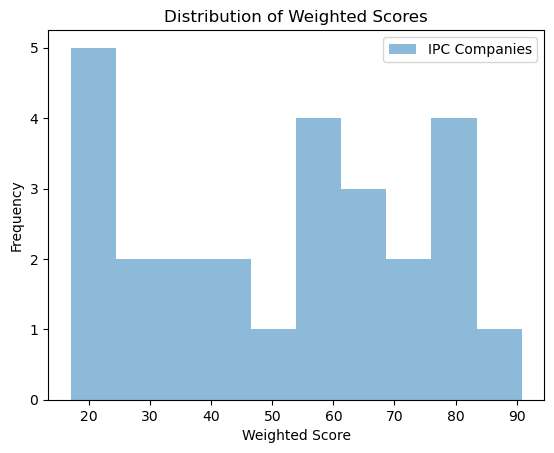

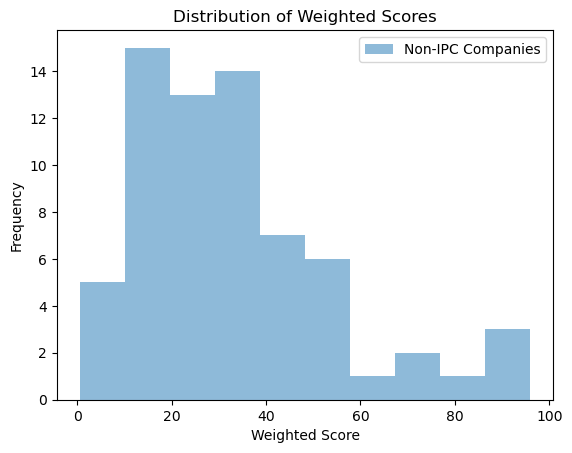

In [17]:
plt.hist(df_companies['weighted_score'], bins=10, alpha=0.5, label='IPC Companies')
plt.xlabel('Weighted Score')
plt.ylabel('Frequency')
plt.title('Distribution of Weighted Scores')
plt.legend()
plt.show()

plt.hist(df_non_ipc_companies['weighted_score'], bins=10, alpha=0.5, label='Non-IPC Companies')
plt.xlabel('Weighted Score')
plt.ylabel('Frequency')
plt.title('Distribution of Weighted Scores')
plt.legend()
plt.show()

## <font color='cornflowerblue'> Payment Plans

In [18]:
inventory_days_list = []
inventory_days_non_ipc_list = []

for ticker in ipc_tickers:
    bs, ist, _ = get_financials(ticker)
    try:
        inventory_turnover = ist.loc['Cost Of Revenue'] / bs.loc['Inventory']
        inventory_days = 365 / inventory_turnover
        inventory_days_list.append(inventory_days.values[0])
    except (KeyError, ZeroDivisionError):
        print(f"Error calculating inventory days for {ticker}")

for ticker in non_ipc_tickers:
    bs, ist, _ = get_financials(ticker)
    try:
        inventory_turnover = ist.loc['Cost Of Revenue'] / bs.loc['Inventory']
        inventory_days = 365 / inventory_turnover
        inventory_days_non_ipc_list.append(inventory_days.values[0])
    except (KeyError, ZeroDivisionError):
        print(f"Error calculating inventory days for {ticker}")

Error calculating inventory days for GAPB.MX
Error calculating inventory days for OMAB.MX
Error calculating inventory days for VESTA.MX
Error calculating inventory days for ALTERNAB.MX
Error calculating inventory days for ESENTIAII.MX
Error calculating inventory days for GICSAB.MX
Error calculating inventory days for GPROFUT.MX
Error calculating inventory days for HCITY.MX
Error calculating inventory days for LASITE.MX
Error calculating inventory days for PLANI.MX
Error calculating inventory days for RCENTROA.MX
Error calculating inventory days for SITES1A-1.MX


In [19]:
inventory_days_non_ipc_list = pd.Series(inventory_days_non_ipc_list)

np.median(inventory_days_list), np.median(inventory_days_non_ipc_list.dropna())

(51.50679234821181, 74.20892641396071)

In [21]:
inventory_turnover = ist.loc['Cost Of Revenue'] / bs.loc['Inventory']
inventory_days = 365 / inventory_turnover
inventory_days

2025-12-31    2.131875
dtype: object

In [22]:
receivables_turnover = ist.loc['Total Revenue'] / bs.loc['Accounts Receivable']
sales_days = 365 / receivables_turnover
sales_days

2025-12-31    7.598209
dtype: object

In [23]:
revenue_per_day = ist.loc['Total Revenue'] / 365
revenue_per_day

2025-12-31    8321961.643836
Name: Total Revenue, dtype: object